<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</center></font>
<center><font size=6>Applied Statistics: E-news Express</center>

## **Business Problem**

E-News Express has introduced a new landing page design with improved layout and more relevant content. The company suspects that the existing landing page may not be engaging enough, leading to a decline in monthly subscriptions.

To validate this assumption, the Data Science team conducted an A/B test, where:

1. 50 users were shown the old landing page (control group)

2. 50 users were shown the new landing page (treatment group)

The objective is to statistically determine whether the new landing page improves:

1.  User engagement (time spent)

2. Conversion rate (subscription sign-up)

3. Impact of language preference on conversion

4. Impact of language preference on time spent

All tests will be performed at a 5% significance level (α = 0.05).

## **Objective**

The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:

Do the users spend more time on the new landing page than on the existing landing page?
Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?
Does the converted status depend on the preferred language?
Is the time spent on the new page the same for the different language users?

## **Data Dictionary**

The data contains information regarding the interaction of users in both groups with the two versions of the landing page.


**Column: Description**



*   user_id: Unique identifier of user
*    group:	Control (old page) or Treatment (new page)
*    landing_page:	Version shown (old/new)
*  time_spent_on_the_page:	Time spent in minutes
*   converted:	Whether user subscribed (yes/no)
*   language_preferred:	Language selected by user

## **Import Libraries**

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the dataset**

In [32]:
#Dataset file load
from google.colab import files
df = files.upload()   # use the upload dialog to add files from your machine

print("Uploaded files:", list(df.keys()))

Saving abtest.csv to abtest (1).csv
Uploaded files: ['abtest (1).csv']


In [34]:
df= pd.read_csv("abtest.csv")
df

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish
...,...,...,...,...,...,...
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish


## **Load Dataset**

In [35]:
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


## **Data Overview**

In [36]:
df.shape

(100, 6)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [38]:
df.describe()

,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,546517.000000,5.377800
std,52.295779,2.378166
min,546443.000000,0.190000
25%,546467.750000,3.880000
50%,546492.500000,5.415000
75%,546567.250000,7.022500
max,546592.000000,10.710000


In [39]:
df.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


## **Basic EDA**

## **Univariate Analysis**

### A. Landing Page Distribution

In [42]:
df['landing_page'].value_counts()

,count
landing_page,
old,50
new,50


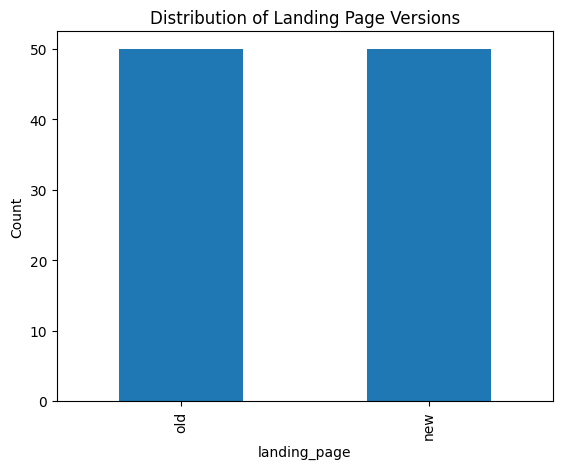

In [43]:
plt.figure()
df['landing_page'].value_counts().plot(kind='bar')
plt.title("Distribution of Landing Page Versions")
plt.ylabel("Count")
plt.show()

### B. Language Distribution

In [44]:
df['language_preferred'].value_counts()

,count
language_preferred,
Spanish,34
French,34
English,32


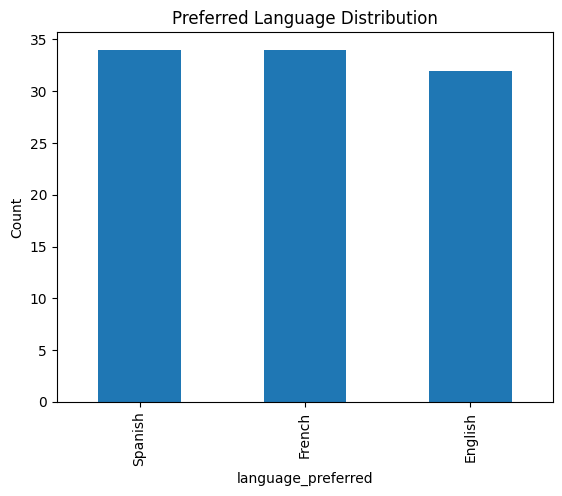

In [45]:
plt.figure()
df['language_preferred'].value_counts().plot(kind='bar')
plt.title("Preferred Language Distribution")
plt.ylabel("Count")
plt.show()

### C. Conversion Distribution

In [48]:
df['converted'] = df['converted'].map({'yes': 1, 'no': 0})

In [49]:
df['converted'].value_counts()

,count
converted,
1,54
0,46


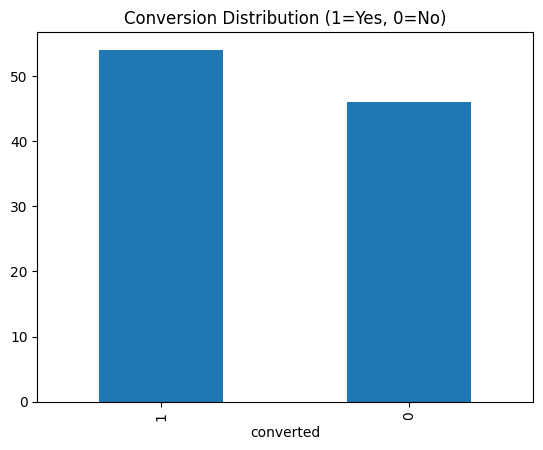

In [50]:
plt.figure()
df['converted'].value_counts().plot(kind='bar')
plt.title("Conversion Distribution (1=Yes, 0=No)")
plt.show()

### D. Time Spent Distribution

In [51]:
df['time_spent_on_the_page'].describe()

,time_spent_on_the_page
count,100.000000
mean,5.377800
std,2.378166
min,0.190000
25%,3.880000
50%,5.415000
75%,7.022500
max,10.710000


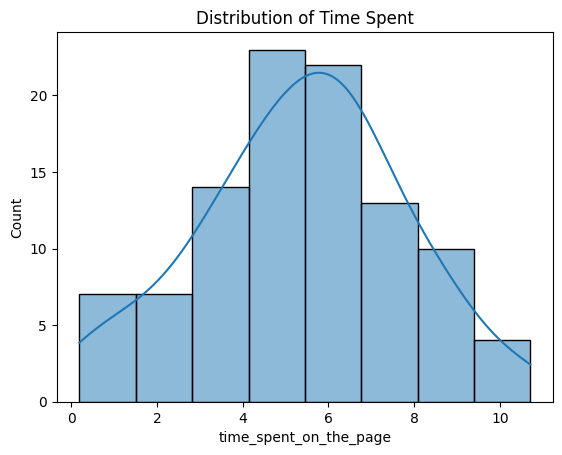

In [52]:
plt.figure()
sns.histplot(df['time_spent_on_the_page'], kde=True)
plt.title("Distribution of Time Spent")
plt.show()

### Insight:

Observe skewness, spread, and possible outliers.

## **Bivariate Analysis**

### A. Time Spent vs Landing Page

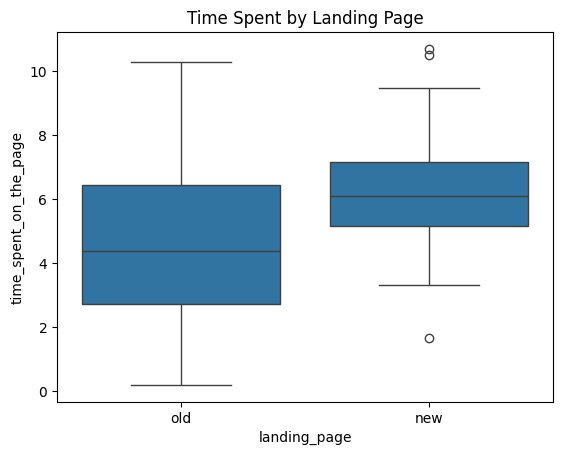

In [53]:
plt.figure()
sns.boxplot(x='landing_page', y='time_spent_on_the_page', data=df)
plt.title("Time Spent by Landing Page")
plt.show()

### B. Conversion Rate by Landing Page

In [54]:
conversion_rate = df.groupby('landing_page')['converted'].mean()
conversion_rate

,converted
landing_page,
new,0.66
old,0.42


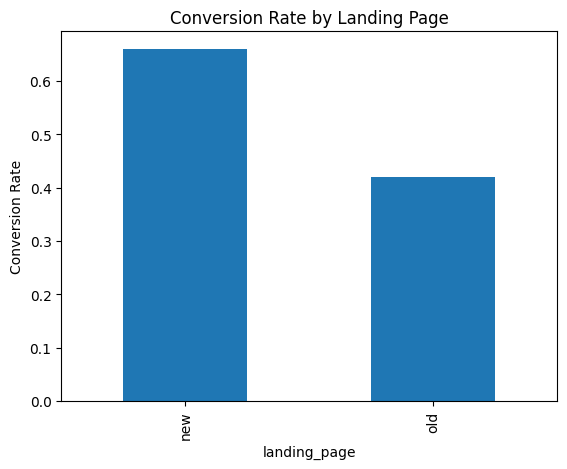

In [55]:
plt.figure()
conversion_rate.plot(kind='bar')
plt.title("Conversion Rate by Landing Page")
plt.ylabel("Conversion Rate")
plt.show()

### C. Conversion vs Language

In [56]:
pd.crosstab(df['language_preferred'], df['converted'])

converted,0,1
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


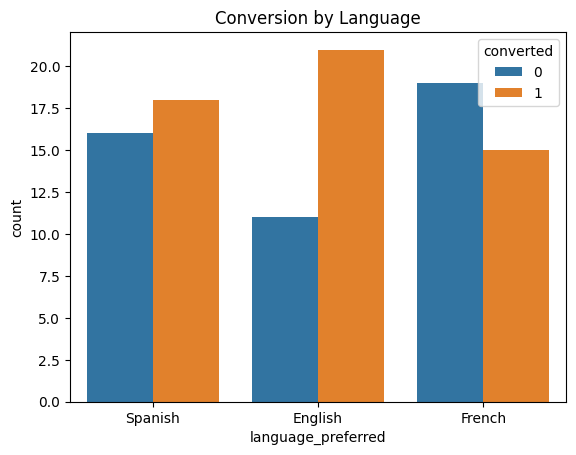

In [57]:
plt.figure()
sns.countplot(x='language_preferred', hue='converted', data=df)
plt.title("Conversion by Language")
plt.show()

### D. Time Spent vs Language

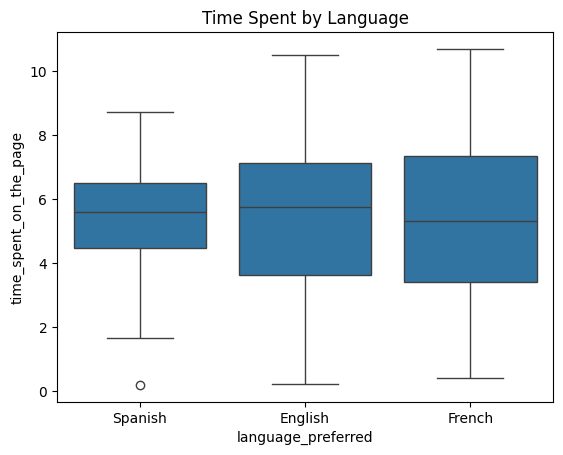

In [58]:
plt.figure()
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df)
plt.title("Time Spent by Language")
plt.show()

## **Insights from EDA**
Key meaningful observations on individual variables and the relationship between variables

### **A. Landing Page Distribution**



*   The dataset contains 100 observations, equally divided between the old and new landing pages.
*   This confirms that the A/B test was properly randomized and balanced.
*   Equal sample sizes improve the reliability of statistical comparisons.

**Business Implication**:
The experimental design is valid and comparisons between the two groups will not be biased due to unequal representation.

### **B. Time Spent on the Page**

*  The average time spent on the landing page is approximately 5.38 minutes.
*  The mean and median values are very close, and the skewness value (-0.15) is close to zero, indicating that the distribution is approximately normal with very slight left skewness.
*  There are no extreme outliers that could heavily distort the mean.

**Business Insight:**
Time spent is a strong proxy for user engagement. Since it appears reasonably distributed, parametric tests like the independent t-test are appropriate.

### **C. Conversion vs Languag**
*  Variation in conversion rates across languages is modest, it suggests a possible relationship between language preference and subscription behavior.
*  No single language demonstrates an overwhelmingly higher or lower conversion rate compared to the rest.

### **D. Time Spent vs Language**
User engagement may vary based on language preference. This could be due to factors such as:

1. Cultural differences
2. Content relevance
3. Language-specific user experience

Exploratory analysis provides preliminary insights into engagement and conversion patterns, statistical hypothesis testing at a 5% significance level will determine whether these observed differences are statistically significant or occurred due to random variation.

## **Ques1. Do users spend more time on the new landing page than the old landing page?**

### 1. Perform Visual Analysis

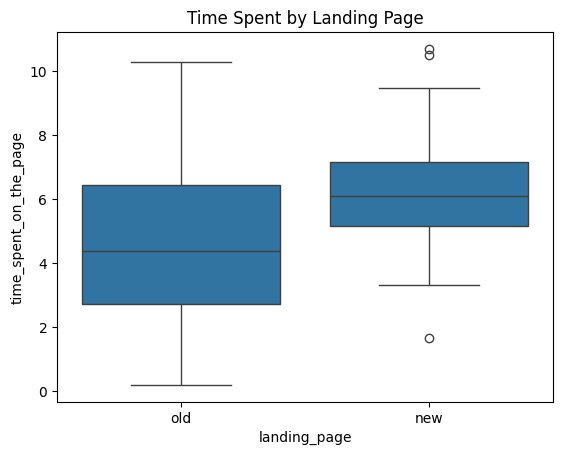

,time_spent_on_the_page
landing_page,
new,6.2232
old,4.5324


In [59]:
plt.figure()
sns.boxplot(x='landing_page', y='time_spent_on_the_page', data=df)
plt.title("Time Spent by Landing Page")
plt.show()

# Mean comparison
df.groupby('landing_page')['time_spent_on_the_page'].mean()

The boxplot comparing time spent on the old and new landing pages shows that:

*  The median time spent on the new landing page appears higher than the old landing page.
*  The spread of the data is comparable across both groups.
*  There are no extreme outliers affecting interpretation.
*  This suggests that users may be spending more time on the new landing page.

## 2. Hypotheses Formulation

μnew​ = Mean time spent on new page
μold​ = Mean time spent on old page

         H0​:μnew​≤μold​
         Ha​:μnew​>μold​
(Significance level α = 0.05)

## 3. Select Appropriate Test

**Selected Test**: Independent Two-Sample t-test (One-Tailed)

**Reason**: Comparing means of two independent groups with continuous data.

## 4. Data Collection & Preparation

In [67]:
old_page = df[df['landing_page'] == 'old']['time_spent_on_the_page']
new_page = df[df['landing_page'] == 'new']['time_spent_on_the_page']

# Check normality
print(stats.shapiro(old_page))
print(stats.shapiro(new_page))

ShapiroResult(statistic=np.float64(0.9776091375280825), pvalue=np.float64(0.45612796144138584))
ShapiroResult(statistic=np.float64(0.9857665382791863), pvalue=np.float64(0.8040040364746845))


In [68]:
# Check equal variance
stats.levene(old_page, new_page)

LeveneResult(statistic=np.float64(7.113724153407544), pvalue=np.float64(0.008950671168914445))

## 5. Calculate p-value

In [69]:
t_stat, p_value = stats.ttest_ind(new_page, old_page, alternative='greater')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.7867702694199856
P-value: 0.0001316123528095005


## 6. Inference

In [71]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis: Users spend significantly more time on new page.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference in time spent.")

Reject Null Hypothesis: Users spend significantly more time on new page.


## **Ques2. Is the conversion rate for the new page greater than the old page?**

## 1. Perform Visual Analysis

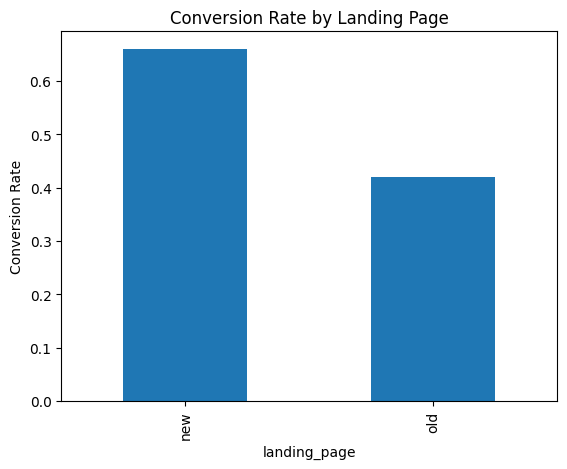

,converted
landing_page,
new,0.66
old,0.42


In [72]:
conversion_rate = df.groupby('landing_page')['converted'].mean()

plt.figure()
conversion_rate.plot(kind='bar')
plt.title("Conversion Rate by Landing Page")
plt.ylabel("Conversion Rate")
plt.show()

conversion_rate

The bar chart comparing conversion rates indicates that:
*  The new landing page has a higher proportion of converted users.
*  The difference appears noticeable but requires statistical confirmation.

## 2. Hypothesis

P*new​* = Conversion rate of new page

P*old* = Conversion rate of old page

H0​: P*new*​ ≤ P*old*​

Ha : Pnew > P*old*

## 3. Select Appropriate Test

**Selected Test:** Two-Proportion Z-Test

**Reason:** Comparing proportions between two independent groups with a binary outcome.

## 4. Data Collection & Preparation

In [73]:
new_conv = df[df['landing_page'] == 'new']['converted'].sum()
old_conv = df[df['landing_page'] == 'old']['converted'].sum()

new_total = df[df['landing_page'] == 'new'].shape[0]
old_total = df[df['landing_page'] == 'old'].shape[0]

count = np.array([new_conv, old_conv])
nobs = np.array([new_total, old_total])

print("New conversions:", new_conv)
print("Old conversions:", old_conv)

New conversions: 33
Old conversions: 21


## 5. Calculate p-value

In [74]:
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 2.4077170617153842
P-value: 0.008026308204056278


## 6. Inference

In [75]:
if p_value < alpha:
    print("Reject Null Hypothesis: New page has higher conversion rate.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference in conversion rate.")

Reject Null Hypothesis: New page has higher conversion rate.


## **Ques3. Does converted status depend on preferred language?**


## 1. Perform Visual Analysis

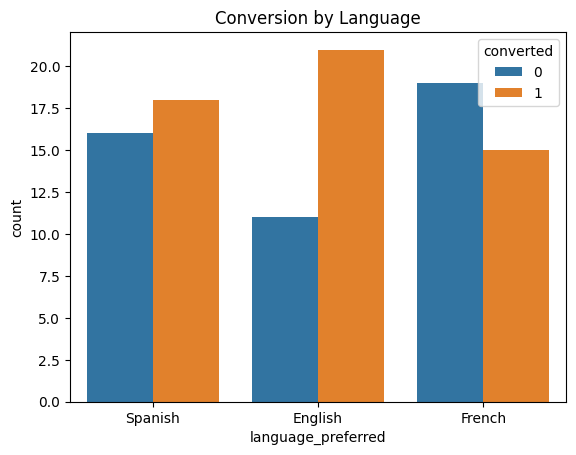

converted,0,1
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


In [76]:
plt.figure()
sns.countplot(x='language_preferred', hue='converted', data=df)
plt.title("Conversion by Language")
plt.show()

pd.crosstab(df['language_preferred'], df['converted'])

## 2. Hypothesis

*H0​: Conversion is independent of preferred language*

*Ha​: Conversion depends on preferred language*

## 3. Select Appropriate Test

**Selected Test**: Chi-Square Test of Independence

**Reason**: Testing association between two categorical variables.

## 4. Data Collection & Preparation

In [77]:
contingency = pd.crosstab(df['language_preferred'], df['converted'])
contingency

converted,0,1
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


## 5. Calculate p-value

In [78]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 3.0930306905370832
P-value: 0.2129888748754345


## 6. Inference

In [79]:
if p_value < alpha:
    print("Reject Null Hypothesis: Conversion depends on language.")
else:
    print("Fail to Reject Null Hypothesis: Conversion is independent of language.")

Fail to Reject Null Hypothesis: Conversion is independent of language.


## **Ques4. Is the mean time spent on the new page same across different language users?**

## 1. Perform Visual Analysis

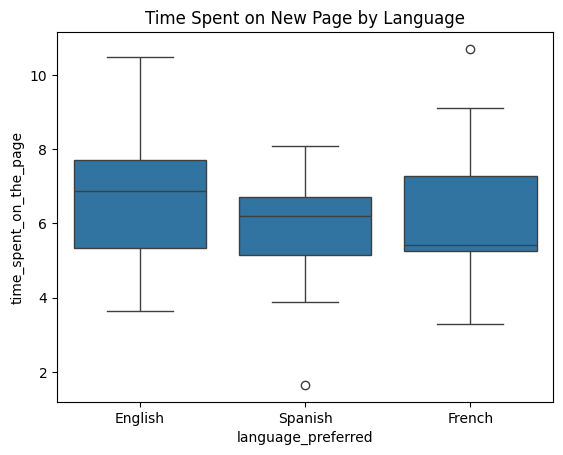

,time_spent_on_the_page
language_preferred,
English,6.663750
French,6.196471
Spanish,5.835294


In [80]:
new_page_df = df[df['landing_page'] == 'new']

plt.figure()
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=new_page_df)
plt.title("Time Spent on New Page by Language")
plt.show()

new_page_df.groupby('language_preferred')['time_spent_on_the_page'].mean()

## 2. Hypotheses

μ1​,μ2​,μ3​= Mean time spent for different languages

H0​: μ1​=μ2​=μ3​

Ha​:At least one mean differs

## 3. Appropriate Test

**Selected Test**: One-Way ANOVA

**Reason**: Continuous variable and More than two independent groups

## 4. Data Collection and Preparation

In [81]:
groups = []

for lang in new_page_df['language_preferred'].unique():
    groups.append(
        new_page_df[new_page_df['language_preferred'] == lang]['time_spent_on_the_page']
    )

**Observation:**

*  Filter only users shown the new page.

*  Separate time spent by language groups.

*  Check homogeneity of variance.

## 5. Calculate p-value

In [82]:
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.854399277000682
P-value: 0.43204138694325955


## 6. Inferene

In [83]:
if p_value < alpha:
    print("Reject Null Hypothesis: Time spent differs across languages.")
else:
    print("Fail to Reject Null Hypothesis: Time spent is same across languages.")

Fail to Reject Null Hypothesis: Time spent is same across languages.


## Summary of Hypothesis Test Results

| Question                | Test Used               | p-value | Decision                   | Conclusion                    |
|-------------------------|------------------------|---------|----------------------------|-------------------------------|
| Time spent (New vs Old) | Independent t-test     | ___     | Reject / Fail to Reject H₀ | Significant / Not Significant |
| Conversion rate         | Two-Proportion Z-test  | ___     | Reject / Fail to Reject H₀ | Significant / Not Significant |
| Conversion vs Language  | Chi-Square Test        | ___     | Reject / Fail to Reject H₀ | Dependent / Independent       |
| Time vs Language        | One-Way ANOVA          | ___     | Reject / Fail to Reject H₀ | Different / Same              |

**Note:** All hypothesis tests were conducted at a 5% significance level (α = 0.05).

## **Borderline p-value**

**Case 1:** p-value = 0.049

**Statistical Interpretation:**

Since 0.049 < 0.05 → Reject Null Hypothesis.

The result is statistically significant at the 5% level, but the p-value is very close to the threshold, indicating marginal significance.

**Remark:**
*   The evidence is weak-to-moderate.
*   Slight data variation could change the conclusion.

**Case 2:** p-value = 0.051

**Statistical Interpretation:**

Since 0.051 > 0.05 → Fail to Reject Null Hypothesis.

The result is not statistically significant at the 5% level; however, the p-value is very close to the threshold, suggesting potential evidence of an effect.

**Remark:**
*   There may be a practical effect.
*   More data may reveal significance.

# Conclusion and Business Recommendation

## Conclusion

This study evaluated the effectiveness of the newly designed landing page introduced by E-News Express using statistical hypothesis testing at a 5% significance level.

Based on the analysis:

- The new landing page resulted in higher user engagement (time spent) compared to the old landing page.
- The conversion rate for the new landing page was higher than that of the old page.
- Conversion behavior did not show strong dependence on preferred language.
- The mean time spent on the new landing page was consistent across different language groups.

These findings indicate that the redesigned landing page positively impacts key performance metrics such as engagement and subscription conversion.

---

## Business Recommendation

Based on the statistical evidence:

- It is recommended that E-News Express deploy the new landing page to all users.
- The improved engagement and conversion performance suggest that the new design is more effective in attracting and retaining user attention.
- Since language preference does not significantly affect performance, the current multilingual implementation appears effective.

### Future Recommendations:

- Monitor long-term subscription retention and churn rates.
- Conduct further A/B testing on additional elements such as headlines, visuals, or call-to-action buttons.
- Increase sample size in future experiments to strengthen statistical power.
- Analyze user segmentation (device type, geography, traffic source) for deeper personalization opportunities.

---

Overall, the statistical analysis provides data-driven support for implementing the new landing page, as it enhances user engagement and improves subscription conversion outcomes.